##می‌خوایم با هم تحلیل داده‌های Falcon 9 رو انجام بدیم و یاد بگیریم چطور با Python، Pandas و SQL داده‌های واقعی فضایی رو بررسی کنیم

#فراخوانی داده ها

In [ ]:
#بارگذاری و بررسی داده‌ها
import pandas as pd
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv")
#df.to_sql("SPACEXTBL", con, if_exists='replace', index=False,method="multi")

In [ ]:
df.info()

## ستونها چی هستند؟

Launch Site: سایت پرتاب

Booster Version: نوع بوستر

Payload Mass: جرم محموله

Landing Outcome: نتیجه فرود مرحله اول

Mission Outcome: موفقیت یا شکست کل ماموریت

In [ ]:
df.head(5)

## Task 1
Display the names of the unique launch sites  in the space mission


In [ ]:
#تمام سایت‌های منحصر به فرد پرتاب را می‌بینی
set(df['Launch_Site'])
#یعنی چهار سایت پرتاب مختلف وجود داره:

## Task 2
Display 5 records where launch sites begin with the string 'CCA'

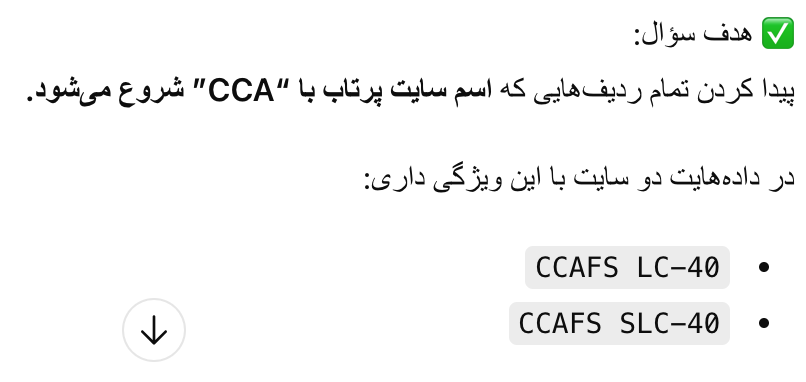

یعنی دقیقاً “شروع شوند با CCA” — نه اینکه هرجا CCA وجود داشت.
پس از نظر معنایی باید بررسی کنیم آیا اولین کاراکترهای رشته برابر با 'CCA' هستند یا نه.

In [ ]:
#عینا اون چیزی که اخر کد میبینی رو میره میگرده پیدا میکنه و برمیگردونه
#df_CCA01= df[df['Launch_Site']=='CCAFS LC-40']

In [ ]:
#ردیف‌هایی را برمی‌گرداند که هرجای متنشان 'CCA' وجود داشته باشد
#df_CCA= df[df['Launch_Site'].str.contains('CCA')]

In [ ]:
#فقط ردیف‌هایی را برمی‌گرداند که با 'CCA' شروع می‌شوند
df_CCA = df[df['Launch_Site'].str.startswith('CCA')]

In [ ]:
df_CCA.head()

In [ ]:
df_CCA

In [ ]:
#میتونی همه مدل چکش کنی
set(df_CCA['Launch_Site'])

## Task 3
Display the total payload mass carried by boosters launched by NASA (CRS)
مجموع کل جرم محموله‌ها (PAYLOAD_MASS__KG_) را نمایش بده که توسط پرتاب‌هایی انجام شده که مشتری‌شان NASA (CRS) بوده است.

In [ ]:
df['PAYLOAD_MASS__KG_'] == 'NASA (CRS)'

In [ ]:
df['Customer'] == 'NASA (CRS)'

In [ ]:
total_mass_nasa = df[df['Customer'] == 'NASA (CRS)']['PAYLOAD_MASS__KG_'].sum()

In [ ]:
print(total_mass_nasa)

## Task 4
Display average payload mass carried by booster version F9 v1.1
مربوط به محاسبه‌ی میانگین جرم محموله برای بوستر خاصیه.

میانگین وزن محموله‌هایی را نمایش بده که توسط بوستر نسخه‌ی F9 v1.1 پرتاب شده‌اند.

In [ ]:
avg_mass_f9v1_1 = df[df['Booster_Version'] == 'F9 v1.1']['PAYLOAD_MASS__KG_'].mean()

In [ ]:
print(avg_mass_f9v1_1)

##Task 5
کی از سؤال‌های قشنگ این مجموعه، چون باید از تابع آماری (min) استفاده کنیم

List the date when the first successful landing outcome in ground pad was achieved.
Hint: Use min function
تاریخی را پیدا کن که اولین فرود موفق (successful landing) روی سکوی زمینی (ground pad) در آن اتفاق افتاده است.

In [ ]:
first_success_ground_pad = df[df['Landing_Outcome'] == 'Success (ground pad)']['Date'].min()
print(first_success_ground_pad)

##Task 6
بریم سراغ Task 6، که کمی پیچیده‌تره چون دو شرط همزمان داره: فرود موفق روی drone ship و جرم محموله بین ۴۰۰۰ تا ۶۰۰۰ کیلوگرم.

بریم سراغ Task 6، که کمی پیچیده‌تره چون دو شرط همزمان داره: فرود موفق روی drone ship و جرم محموله بین ۴۰۰۰ تا ۶۰۰۰ کیلوگرم.

نام بوسترهایی را پیدا کن که:

فرود موفق روی کشتی پهپاد (drone ship) داشته‌اند،

جرم محموله‌شان بین ۴۰۰۰ و ۶۰۰۰ کیلوگرم بوده است.

In [ ]:
boosters_success_drone = df[
    (df['Landing_Outcome'] == 'Success (drone ship)') &
    (df['PAYLOAD_MASS__KG_'] > 4000) &
    (df['PAYLOAD_MASS__KG_'] < 6000)
]['Booster_Version']

print(boosters_success_drone)


##Task 7
List the total number of successful and failure mission outcomes

ترجمه:
تعداد کل مأموریت‌های موفق و ناموفق را نمایش بده.
یعنی می‌خوای ببینی هر نوع Mission_Outcome چند رکورد دارد.



In [ ]:
mission_counts = df['Mission_Outcome'].value_counts()
print(mission_counts)

GROUP BY هر نوع نتیجه مأموریت را جدا می‌کند.

COUNT(*) تعداد رکوردهای هر نوع را می‌شمارد.

##Task 8
List all the booster_versions that have carried the maximum payload mass, using a subquery with a suitable aggregate function.
تمام نسخه‌های بوستر (booster_version) را پیدا کن که بیشترین جرم محموله (payload mass) را حمل کرده‌اند،
و برای این کار از یک زیرپرس‌وجو (subquery) همراه با یک تابع تجمیعی مثل MAX() استفاده کن.

In [ ]:
# مرحله 1: پیدا کردن بیشترین جرم محموله
max_payload = df['PAYLOAD_MASS__KG_'].max()

# مرحله 2: پیدا کردن بوسترهایی که این جرم محموله را حمل کرده‌اند
boosters_max_payload = df[df['PAYLOAD_MASS__KG_'] == max_payload]['Booster_Version']

print(boosters_max_payload)


##Task 9

List the records which will display the month names, failure landing_outcomes in drone ship ,booster versions, launch_site for the months in year 2015.

**Note: SQLLite does not support monthnames. So you need to use  substr(Date, 6,2) as month to get the months and substr(Date,0,5)='2015' for year.**

رکوردهایی را پیدا کن که شامل این ستون‌ها باشند:

شماره ماه (یا نام ماه)،

فرود ناموفق (failure) روی کشتی پهپاد (drone ship)،

نسخه بوستر (booster_version)،

سایت پرتاب (launch_site)،
برای ماه‌های سال ۲۰۱۵.

In [ ]:
# مرحله 1: فقط رکوردهای سال 2015
df_2015 = df[df['Date'].str.startswith('2015')]

# مرحله 2: فقط رکوردهایی که فرود ناموفق روی drone ship دارند
df_failure_drone = df_2015[df_2015['Landing_Outcome'] == 'Failure (drone ship)']

# مرحله 3: اضافه کردن ستون شماره ماه
df_failure_drone['Month'] = df_failure_drone['Date'].str[5:7]

# مرحله 4: ستون‌های مورد نظر را انتخاب می‌کنیم
df_task9 = df_failure_drone[['Month', 'Landing_Outcome', 'Booster_Version', 'Launch_Site']]

df_task9.head()


/tmp/ipython-input-1896863755.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_failure_drone['Month'] = df_failure_drone['Date'].str[5:7]


,Month,Landing_Outcome,Booster_Version,Launch_Site
13,01,Failure (drone ship),F9 v1.1 B1012,CCAFS LC-40
16,04,Failure (drone ship),F9 v1.1 B1015,CCAFS LC-40


## Task 10
Rank the count of landing outcomes (such as Failure (drone ship) or Success (ground pad)) between the date 2010-06-04 and 2017-03-20, in descending order.

تعداد هر نوع نتیجه فرود (Landing_Outcome) مثل Failure (drone ship) یا Success (ground pad) را بین تاریخ‌های ۴ ژوئن ۲۰۱۰ تا ۲۰ مارس ۲۰۱۷ بشمار و آنها را بر اساس تعداد نزولی رتبه‌بندی کن.

In [ ]:
# مرحله 1: فیلتر رکوردها بین دو تاریخ
df_filtered = df[(df['Date'] >= '2010-06-04') & (df['Date'] <= '2017-03-20')]

# مرحله 2: شمارش هر نوع Landing_Outcome
landing_counts = df_filtered['Landing_Outcome'].value_counts().reset_index()
landing_counts.columns = ['Landing_Outcome', 'Count']

# مرحله 3: رتبه‌بندی بر اساس Count به ترتیب نزولی
landing_counts['Rank'] = landing_counts['Count'].rank(method='dense', ascending=False)

print(landing_counts)


          Landing_Outcome  Count  Rank
0              No attempt     10   1.0
1    Failure (drone ship)      5   2.0
2    Success (drone ship)      5   2.0
3      Controlled (ocean)      3   3.0
4    Success (ground pad)      3   3.0
5     Failure (parachute)      2   4.0
6    Uncontrolled (ocean)      2   4.0
7  Precluded (drone ship)      1   5.0
